Below is a reference that goes through the main FITS header keys 
and HDU extension names used/created by the code below. 

------------------------------------------------------------------------------
Header Keywords (Primary HDU):
------------------------------------------------------------------------------
- Date-Beg     : The start time of the exposure in ISO format (e.g., 2023-01-01T00:00:00.000).
- Date-Mid     : The midpoint of the exposure in ISO format.

------------------------------------------------------------------------------
Science Data Extensions (Original / Input Data):
------------------------------------------------------------------------------
- GREEN_SCI_WAVE1 : 2D array of wavelengthsfor the GREEN chip, fiber 1 (SCI1). 
                    Each order is one row in that 2D array. 
- GREEN_SCI_WAVE2 : Same as above but for SCI2.
- GREEN_SCI_WAVE3 : Same as above but for SCI3.
- GREEN_SCI_FLUX1 : 2D array of observed flux for fiber 1 on the GREEN chip.
- GREEN_SCI_FLUX2 : Same as above but for SCI2.
- GREEN_SCI_FLUX3 : Same as above but for SCI3.

- RED_SCI_WAVE1   : All the same as the green chip 
- RED_SCI_WAVE2   : 
- RED_SCI_WAVE3   : 
- RED_SCI_FLUX1   : 
- RED_SCI_FLUX2   : 
- RED_SCI_FLUX3   :

------------------------------------------------------------------------------
Blaze-Divided Extensions (Created/Updated by remove_blaze):
------------------------------------------------------------------------------
For each science fiber (SCI1, SCI2, SCI3) and chip (GREEN, RED), the code
creates the following extensions:

- SCIx_GREEN_FLUX_DIV       : 2D array of flux divided by the fitted blaze function 
- SCIx_GREEN_FLUX_DIV_NORM  : 2D array of the above flux, normalized by its median.
- SCIx_RED_FLUX_DIV         : 2D array of flux divided by the fitted blaze function 
- SCIx_RED_FLUX_DIV_NORM    : 2D array of the flux on the Red Chip, normalized by its median.

x is 1, 2, or 3, depending on the fiber. 

------------------------------------------------------------------------------
Continuum-Normalized Extensions (Created/Updated by continuum_norm):
------------------------------------------------------------------------------
- SCIx_GREEN_FLUX_CONT_NORM : 2D array of continuum-normalized flux for the 
                              GREEN chip, fiber x.
- SCIx_RED_FLUX_CONT_NORM   : 2D array of continuum-normalized flux for the 
                              RED chip, fiber x.

In these arrays, the flux in each order has been divided by a continuum fit (left over after blaze removal) 
so that the local continuum is near unity.

------------------------------------------------------------------------------
Interpolated Extensions (Created/Updated by interpolate_flux):
------------------------------------------------------------------------------
- WAVE_INTERP_SCIx : 1D array of the newly defined wavelength grid (after gaps 
                     have been filled and a log-step grid has been chosen).
- FLUX_INTERP_SCIx : 1D array of flux interpolated onto the above wavelength grid, 
                     averaged over orders, for fiber x.

Here, x again is 1, 2, or 3, depending on the fiber. No more chip information since Green + Red were combined

In [1]:
from cleaning_funcs import *
from plotting_tools import *

In [2]:
path = '/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data'# path to your daata
data = read_kpf_data(path)

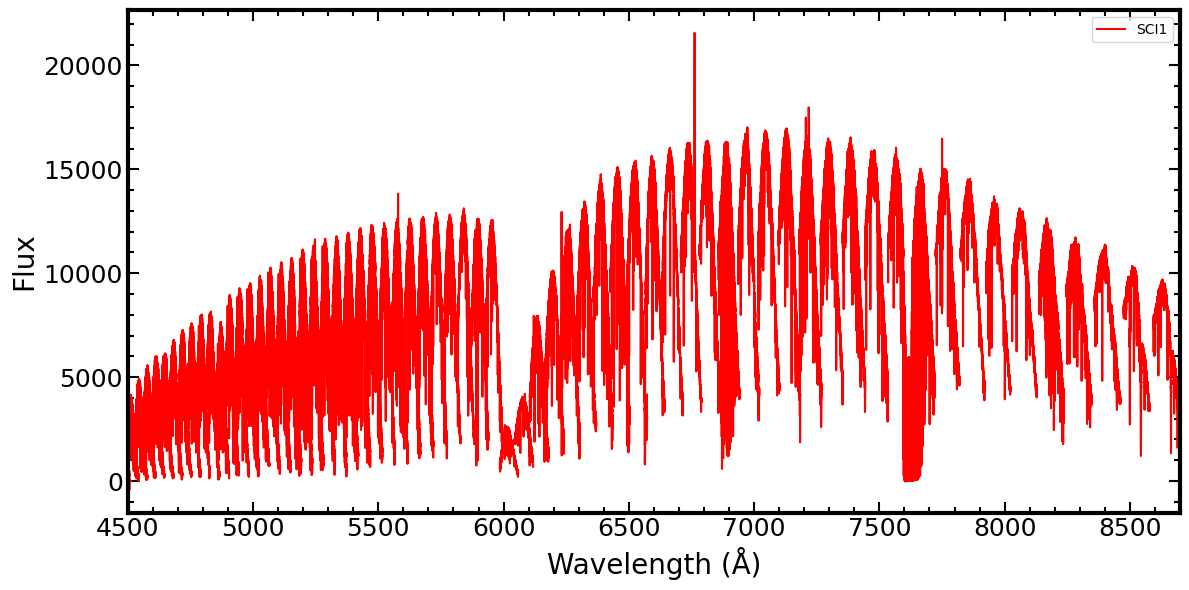

<Axes: xlabel='Wavelength (Å)', ylabel='Flux'>

In [3]:
plot_spectra(data, 
             'KP.20230912.49738.34_L1.fits', # random file
             green_order_range=(0, 35), red_order_range=(0, 32), 
             xlim=(4500,8700), ylim=None, legend=True, fiber=('SCI1',)
            )
# just a dummy plotting function that can be helpful for zooming on raw data 

Seconds to execute savefig: 1.7


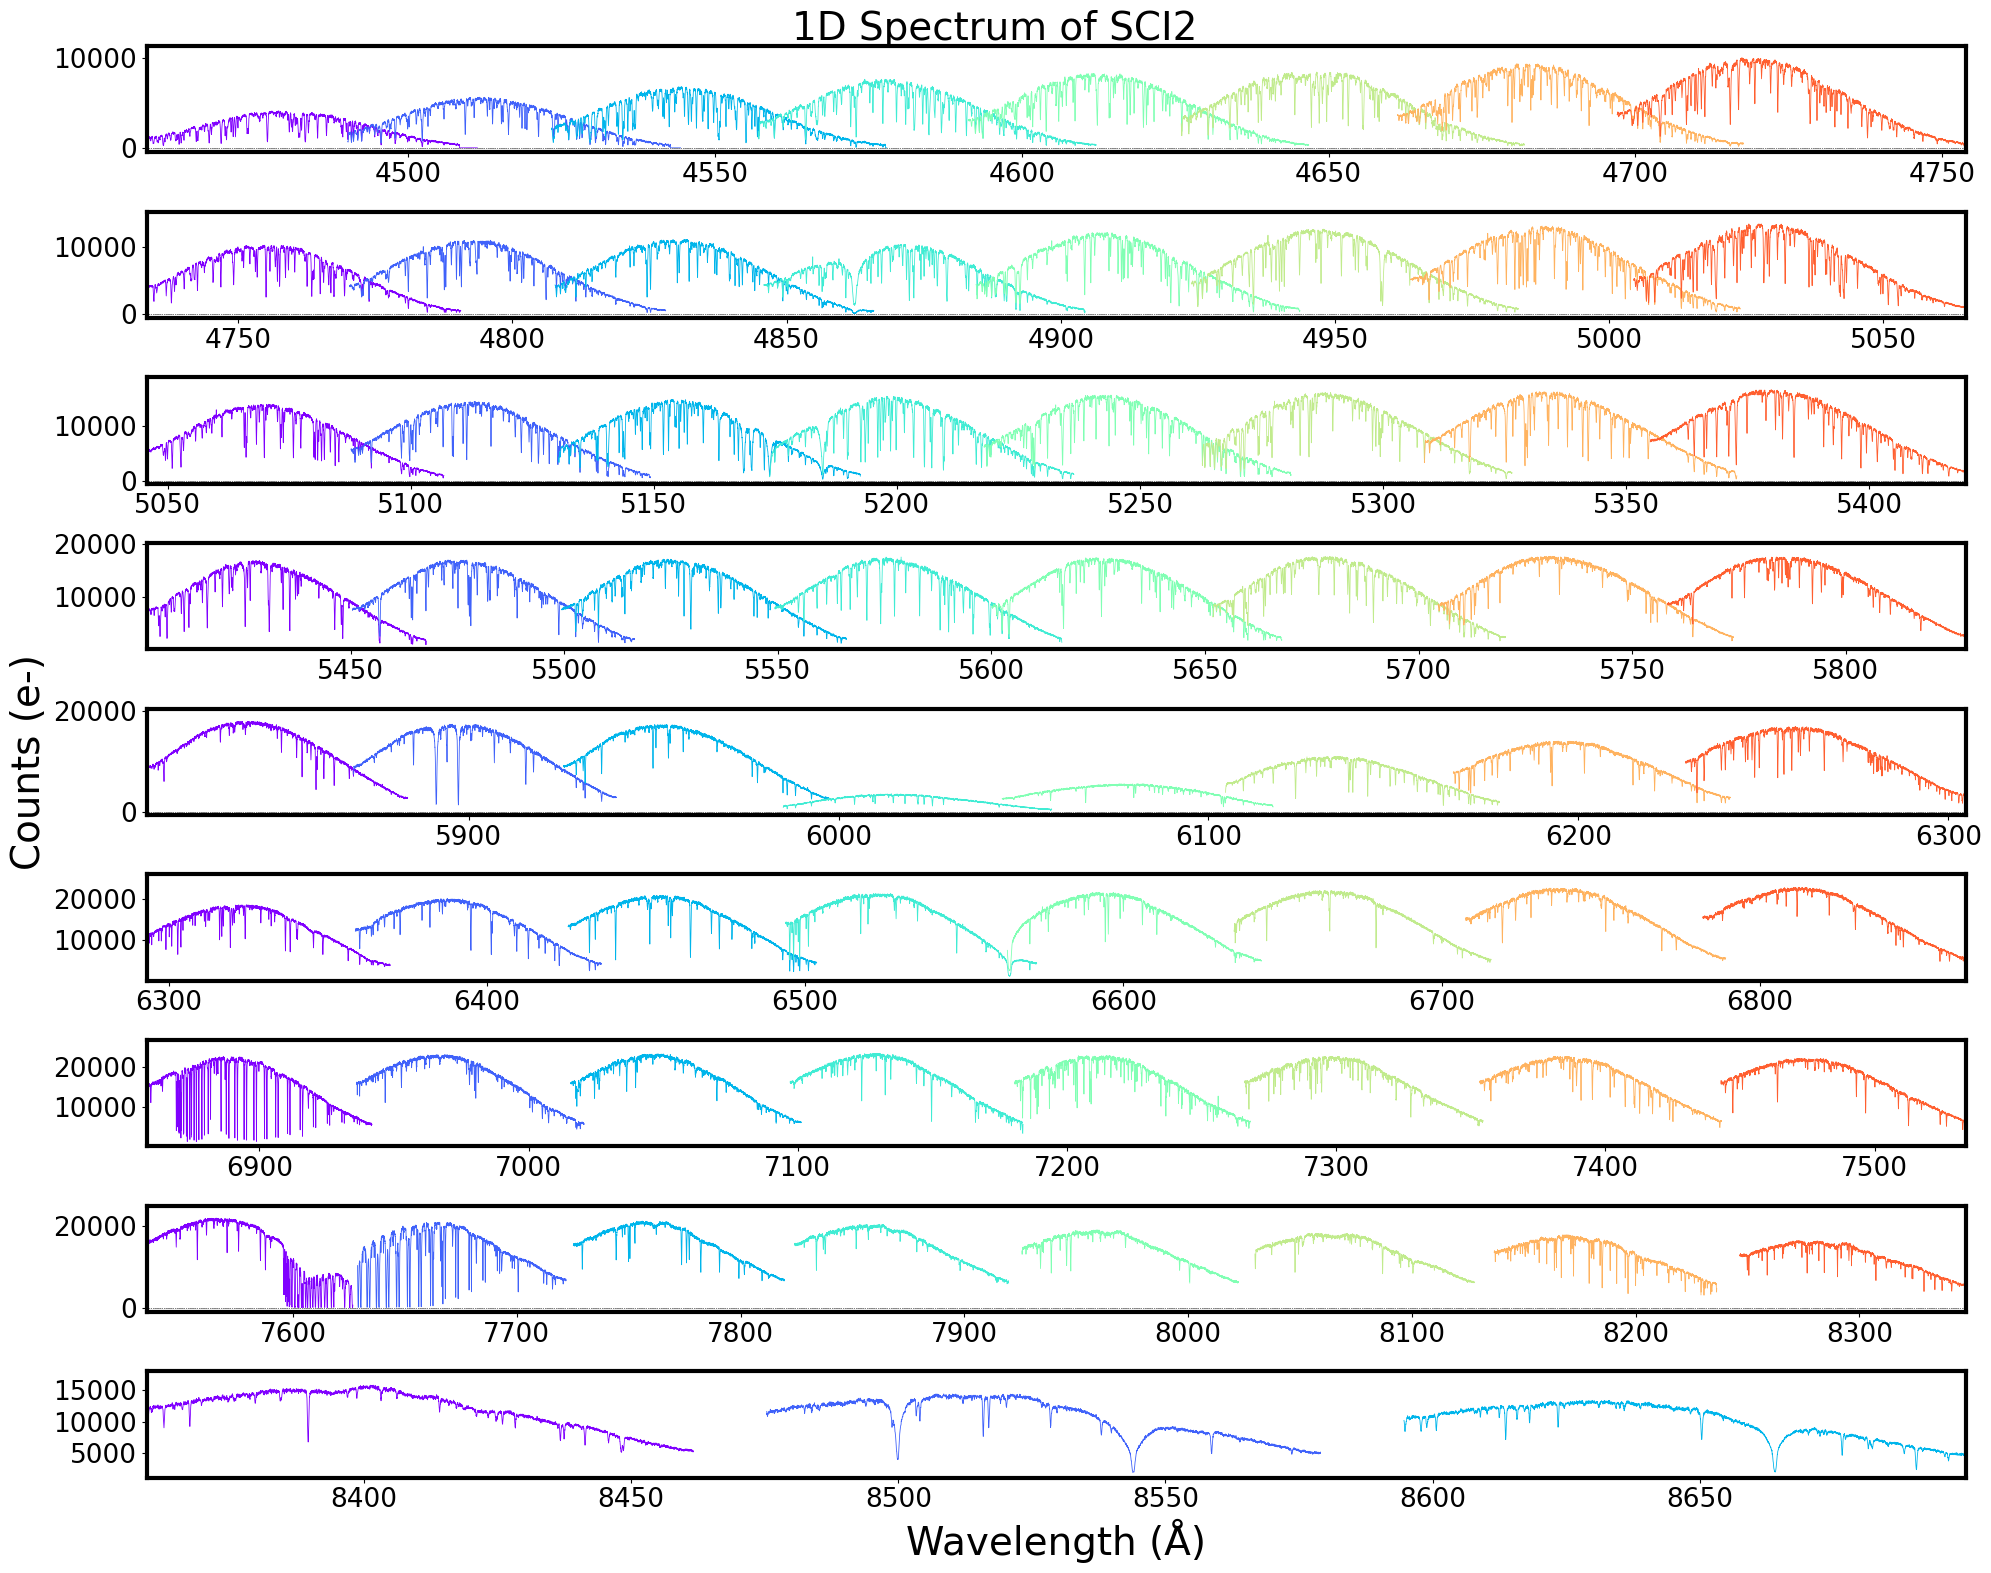

In [4]:
# read in and plot smooth lamp file just to make sure everything looks okay
L1 = '/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data/KP.20230912.49738.34_L1.fits'
plot_L1_spectrum(L1, orderlet='SCI2', fig_path='Figure1.pdf')
# path = '/Users/aaronhouseholder/Desktop/ultra-hot/wasp-14/smooth_lamp'# path to your daata


# smooth_lamp = read_kpf_data(path)
# plot_spectra(smooth_lamp, 
#              'kpf_20250501_smooth_lamp_L1.fits', # random file
#              green_order_range=(0, 35), red_order_range=(0, 0), 
#              xlim=(4500,4600), ylim=None, legend=True, fiber=('SCI1',)
#             )
# # just a dummy plotting function that can be helpful for zooming on raw data 

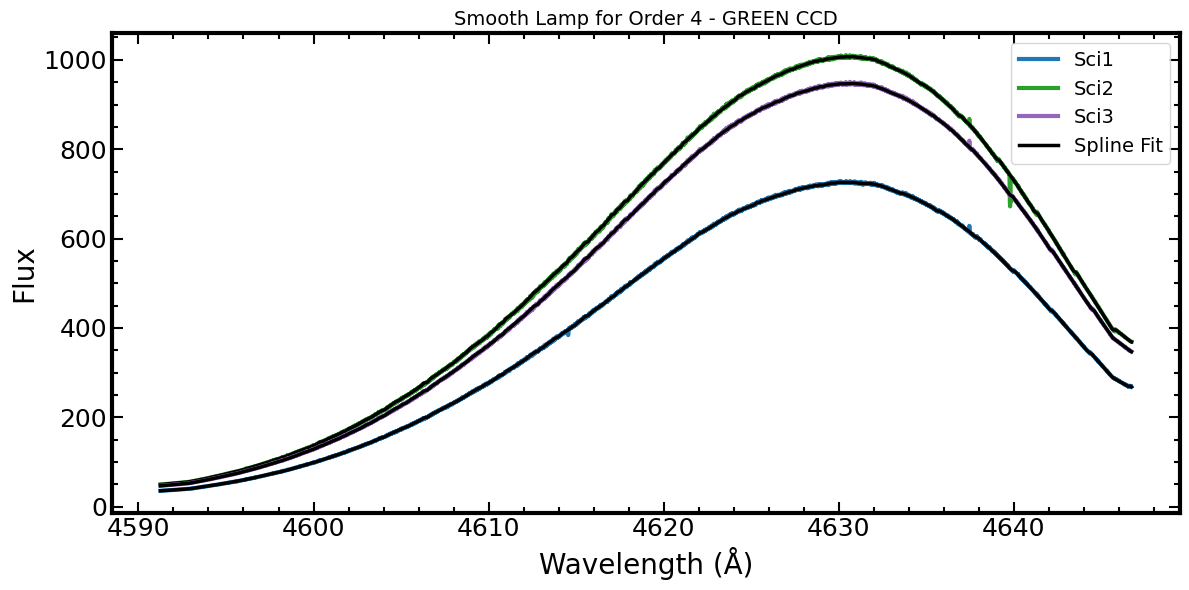


Fitting Spline to Many Orders:  88%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                     | 28/32 [00:04<00:00,  5.96it/s]

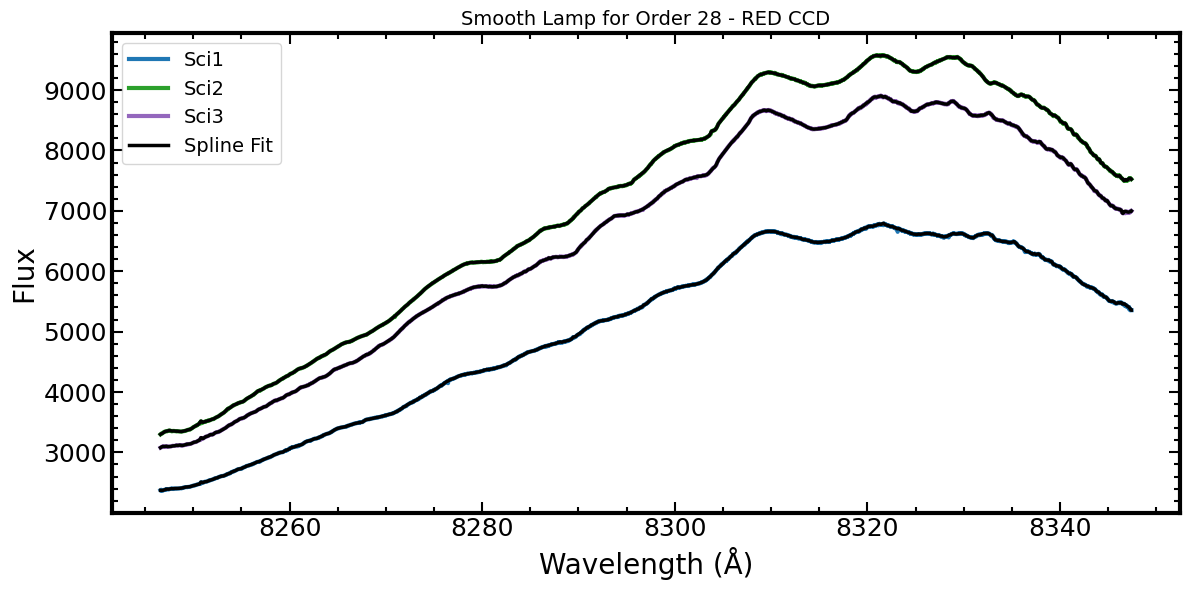


Fitting Spline to Many Orders: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:05<00:00,  5.92it/s]


In [6]:
# fit splines to smooth lamp file order by order (to avoid any white noise/features that aren't the blaze
# e.g., you can see some bad pixels in the plot below that aren't in the science data)
# splines will be used to divide out blaze

smooth_lamp = ['/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/smooth_lamp/kpf_20230912_smooth_lamp_L1.fits'] 

splines_green = fit_spline_many_orders(
    fits_files = smooth_lamp, # smooth lamp to be fit, 
    chip = 'GREEN', # chip to be fit,
    order_range = range(0,35), # orders to be fit, 35 orders on the red chip (0-34)
    plot_orders = [4], #orders to plot
    window_length = 0.15,
    use_matplotlib=True # oops this version only has matplotlib/doesn't actually have plotly
)
    
splines_red = fit_spline_many_orders(
    fits_files = smooth_lamp, # smooth lamp to be fit, 
    chip ='RED', # chip to be fit,
    order_range = range(32), # orders to be fit, 32 orders on the red chip (0-31)
    plot_orders = [28], #orders to plot
    window_length = 0.15,
    time = True, # if you want to see how much time it takes to run the code; should only be a few seconds
    use_matplotlib=True # oops this version only has matplotlib/doesn't actually have plotly
)

Lots of fringing in the red, which is to be expected! 

In [7]:
directory = '/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data' # Define the directory containing all of your science data
remove_blaze(directory, splines_green, splines_red)


Dividing original data by blaze function:   0%|                            | 0/59 [00:00<?, ?file/s]
Dividing original data by blaze function:   2%| | 1/59 [00:00<00:04, 12.63file/s, Elapsed Time=0.07 
Dividing original data by blaze function:   3%| | 2/59 [00:00<00:05,  9.82file/s, Elapsed Time=0.07 
Dividing original data by blaze function:   3%| | 2/59 [00:00<00:05,  9.82file/s, Elapsed Time=0.07 
Dividing original data by blaze function:   5%| | 3/59 [00:00<00:06,  8.95file/s, Elapsed Time=0.07 
Dividing original data by blaze function:   5%| | 3/59 [00:00<00:06,  8.95file/s, Elapsed Time=0.07 
Dividing original data by blaze function:   7%| | 4/59 [00:00<00:06,  8.55file/s, Elapsed Time=0.07 
Dividing original data by blaze function:   7%| | 4/59 [00:00<00:06,  8.55file/s, Elapsed Time=0.08 
Dividing original data by blaze function:   8%| | 5/59 [00:00<00:06,  8.53file/s, Elapsed Time=0.08 
Dividing original data by blaze function:   8%| | 5/59 [00:00<00:06,  8.53file/s, Elapsed 

Dividing original data by blaze function:  68%|▋| 40/59 [00:05<00:02,  8.36file/s, Elapsed Time=0.07
Dividing original data by blaze function:  68%|▋| 40/59 [00:05<00:02,  8.36file/s, Elapsed Time=0.07
Dividing original data by blaze function:  69%|▋| 41/59 [00:05<00:02,  8.41file/s, Elapsed Time=0.07
Dividing original data by blaze function:  69%|▋| 41/59 [00:05<00:02,  8.41file/s, Elapsed Time=0.07
Dividing original data by blaze function:  71%|▋| 42/59 [00:05<00:02,  8.48file/s, Elapsed Time=0.07
Dividing original data by blaze function:  71%|▋| 42/59 [00:05<00:02,  8.48file/s, Elapsed Time=0.07
Dividing original data by blaze function:  73%|▋| 43/59 [00:05<00:01,  8.47file/s, Elapsed Time=0.07
Dividing original data by blaze function:  73%|▋| 43/59 [00:05<00:01,  8.47file/s, Elapsed Time=0.07
Dividing original data by blaze function:  75%|▋| 44/59 [00:05<00:01,  8.33file/s, Elapsed Time=0.07
Dividing original data by blaze function:  75%|▋| 44/59 [00:05<00:01,  8.33file/s, Elapsed 

Data has been divided by the blaze function, normalized, and saved in the directory: /Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data


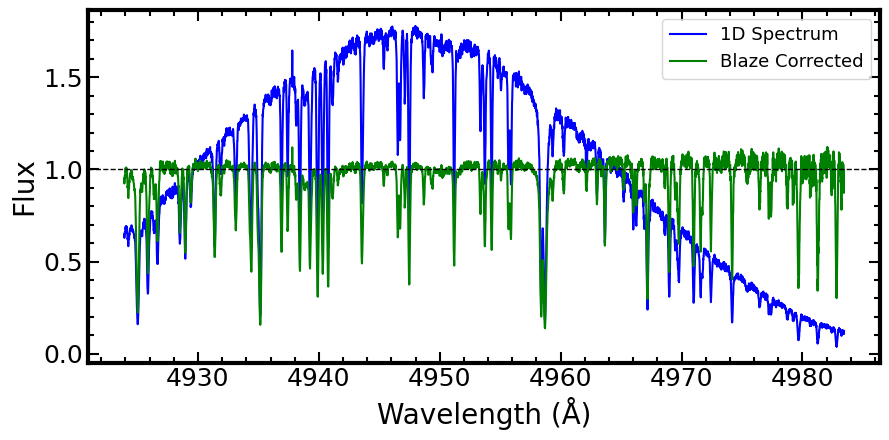

In [8]:
plot_data_stages('/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data/KP.20230912.49738.34_L1.fits', # file
                 'SCI2', # fiber
                'Green', # chip
                order=13,# order number
                stages=('original', 'divided')) 

# can plot the og data/data divided by smooth lamp to see difference
# can see some strong residual trends in the continuum that need to be corrected

In [9]:
# smooth lamp and w76 have different SEDs, so there are still broad trends like the order above. 
# b/c of this i typically do another round of continuum normalization
# you can also turn plot = True to generate the few hundred plots. i usually like to scroll
# through them to make sure the continuum fitting looks okay by eye (and it can helpful to handtweak some of 
# the specific order windows) but turn it off when it's working okay.  
# takes a few seconds cuz median is so slow

continuum_norm(
    directory=directory,
    order_range_green=(0, 35),
    order_range_red=(0, 32),
    window=10,
    n_iter=5,
    ffrac=0.9875,
    plot = False,
    skip_orders_green=[10,11],
    skip_orders_red=[8,9,13,21,22],
    specific_order_windows={("GREEN", 10): 30, ("GREEN", 11): 10,("GREEN", 19): 8, ("RED", 30): 20, ("RED", 31): 20}, 
                                                                # change windows for certain orders    
                                                                # (e.g. for lines like ca+ that are super broad)  
)

Reading in all spectra and calculating Master median flux spectrum for GREEN_SCI1...
Reading in all spectra and calculating Master median flux spectrum for RED_SCI1...



Continuum Normalizing Individual Spectra for SCI1:   0%|                                                                                                                                                               | 0/59 [00:00<?, ?it/s]
Continuum Normalizing Individual Spectra for SCI1:   3%|█████                                                                                                                                                  | 2/59 [00:00<00:04, 13.21it/s]
Continuum Normalizing Individual Spectra for SCI1:   7%|██████████▏                                                                                                                                            | 4/59 [00:00<00:04, 12.24it/s]
Continuum Normalizing Individual Spectra for SCI1:  10%|███████████████▎                                                                                                                                       | 6/59 [00:00<00:04, 11.92it/s]
Continuum Normalizing Individual Spectra fo

Reading in all spectra and calculating Master median flux spectrum for GREEN_SCI2...
Reading in all spectra and calculating Master median flux spectrum for RED_SCI2...



Continuum Normalizing Individual Spectra for SCI2:   0%|                                                                                                                                                               | 0/59 [00:00<?, ?it/s]
Continuum Normalizing Individual Spectra for SCI2:   3%|█████                                                                                                                                                  | 2/59 [00:00<00:04, 12.99it/s]
Continuum Normalizing Individual Spectra for SCI2:   7%|██████████▏                                                                                                                                            | 4/59 [00:00<00:04, 12.09it/s]
Continuum Normalizing Individual Spectra for SCI2:  10%|███████████████▎                                                                                                                                       | 6/59 [00:00<00:04, 11.89it/s]
Continuum Normalizing Individual Spectra fo

Reading in all spectra and calculating Master median flux spectrum for GREEN_SCI3...
Reading in all spectra and calculating Master median flux spectrum for RED_SCI3...



Continuum Normalizing Individual Spectra for SCI3:   0%|                                                                                                                                                               | 0/59 [00:00<?, ?it/s]
Continuum Normalizing Individual Spectra for SCI3:   3%|█████                                                                                                                                                  | 2/59 [00:00<00:04, 13.61it/s]
Continuum Normalizing Individual Spectra for SCI3:   7%|██████████▏                                                                                                                                            | 4/59 [00:00<00:04, 12.46it/s]
Continuum Normalizing Individual Spectra for SCI3:  10%|███████████████▎                                                                                                                                       | 6/59 [00:00<00:04, 12.00it/s]
Continuum Normalizing Individual Spectra fo

All files have been normalized and saved in: /Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data


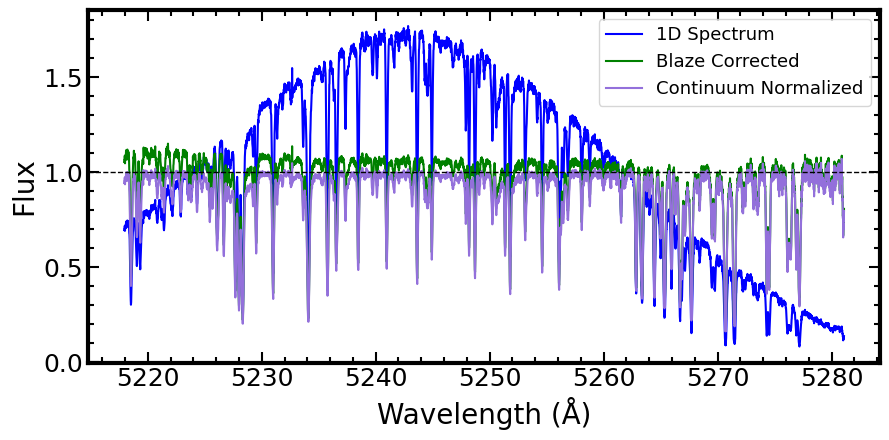

In [10]:
plot_data_stages('/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data/KP.20230912.49738.34_L1.fits', # file
                'SCI2', # fiber
                'Green', # chip
                order=20) # order number

# visualizes what you did above! 

In [11]:
exclusions = {
    # SCI1 chip interpolation exclusion regions
    ('GREEN', 'SCI1', 0): (4504, 'max'),
    ('GREEN', 'SCI1', 1): (4538, 'max'),
    ('GREEN', 'SCI1', 2): (4574, 'max'),
    ('GREEN', 'SCI1', 3): (4605, 'max'),
    ('GREEN', 'SCI1', 4): (4640, 'max'),
    ('GREEN', 'SCI1', 5): (4672, 'max'),
    ('GREEN', 'SCI1', 6): (4708, 'max'),
    ('GREEN', 'SCI1', 7): (4750, 'max'),
    ('RED',   'SCI1', 0): (6046, 'max'),
    ('RED',   'SCI1', 0): (6106, 'max'),

    # SCI2 chip interpolation exclusion regions
    ('GREEN', 'SCI2', 0): (4504, 'max'),
    ('GREEN', 'SCI2', 1): (4538, 'max'),
    ('GREEN', 'SCI2', 2): (4574, 'max'),
    ('GREEN', 'SCI2', 3): (4605, 'max'),
    ('GREEN', 'SCI2', 4): (4640, 'max'),
    ('GREEN', 'SCI2', 5): (4672, 'max'),
    ('GREEN', 'SCI2', 6): (4708, 'max'),
    ('GREEN', 'SCI2', 7): (4750, 'max'),
    ('RED',   'SCI2', 0): (6046, 'max'),
    ('RED',   'SCI2', 0): (6106, 'max'),   
    
    # SCI3 chip interpolation exclusion regions
    ('GREEN', 'SCI3', 0): (4504, 'max'),
    ('GREEN', 'SCI3', 1): (4538, 'max'),
    ('GREEN', 'SCI3', 2): (4570, 'max'),
    ('GREEN', 'SCI3', 3): (4605, 'max'),
    ('GREEN', 'SCI3', 4): (4640, 'max'),
    ('GREEN', 'SCI3', 5): (4672, 'max'),
    ('GREEN', 'SCI3', 6): (4708, 'max'),
    ('GREEN', 'SCI3', 7): (4750, 'max'),
    ('RED',   'SCI3', 0): (6046, 'max'),
    ('RED',   'SCI3', 0): (6106, 'max'),   

}


# exclusions just remove some of the data toward the edges of the orders. typically, i just remove the regions 
# where the continuum fit performed poorly (often due to low SNR in the green orders or the first order on the red chip)
# luckily for WASP-76, these regions are covered by the higher SNR region of an adjacent order so nbd to remove them.
# maybe have to be a little more careful depending on the SED of the star

interpolate_flux('/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data/', step=np.log(1.06), exclusions=exclusions)

# fyi this warning isn't a problem... just happens b/c wave_gap can be < 0 on the green chip but we only
# care about when wave_gap is large


Interpolating Flux for Files:   0%|                                                                                                                                                                                    | 0/59 [00:00<?, ?it/s]/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/cleaning_funcs.py:536: RuntimeWarning: invalid value encountered in log10
  if np.log10(wave_gap) > log_gap_threshold:
/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/cleaning_funcs.py:606: RuntimeWarning: Mean of empty slice
  flux_combined = np.nanmean(flux_interpolated, axis=0)

Interpolating Flux for Files:  53%|█████████████████████████████████████████████████████████████████████████████████████████▊                                                                                 | 31/59 [00:07<00:06,  4.21it/s]


Interpolating Flux for Files: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [00:13<00:00,  4.24it/s]

Interpolation completed and data saved to FITS files in the directory: /Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data/


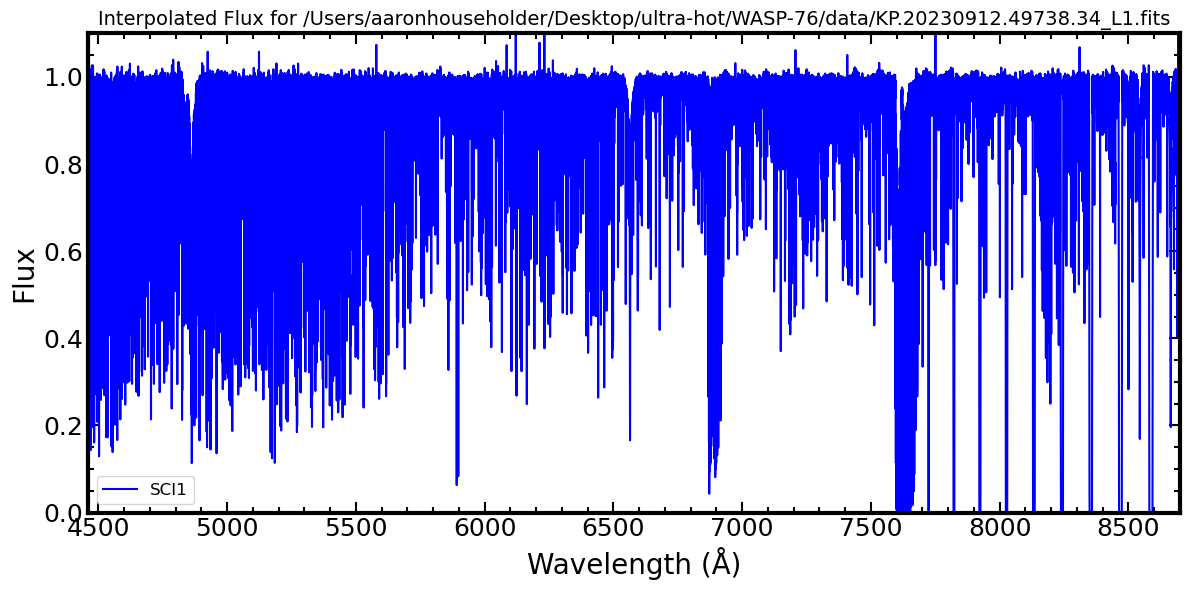

In [12]:
plot_interpolated_flux('/Users/aaronhouseholder/Desktop/ultra-hot/WASP-76/data/KP.20230912.49738.34_L1.fits', 
                       xlim = (4460, 8700), ylim = (0,1.1), fibers = ['SCI1'])
# nice and flat! 